# LCQHNN — MNIST / Fashion-MNIST Fixed (Colab Ready)

**Three fixes applied:**
1. All models trained on the **same** 5,000-sample stratified subset — fair comparison
2. Test subset is stratified random (200 per class), not sequential first-2000
3. LCQHNN_NoQ ablation model — quantum layer replaced with classical 4→4 MLP

**How to run both datasets:**
- Cell 4 has a single `DATASET = 'mnist'` variable
- Run the full notebook once with `'mnist'`, once with `'fashion'`
- Everything else (models, training, evaluation) is identical

**Runtime per dataset on Colab free T4 GPU:**
| Section | Time |
|---|---|
| 5 models × 25 epochs | ~74 min |
| Multi-seed robustness (3 seeds) | ~75 min |
| **Total per dataset** | **~2.5h ✅** |

Quantum circuits always run on CPU — GPU only helps classical layers.


In [1]:
!pip install pennylane pennylane-lightning torchvision seaborn scikit-learn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 101.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import pennylane as qml
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# ── FIX: fixed random seed everywhere for reproducibility ──────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Data loading

### FIX 1 — Equal training data for all models
All four models (CNN, QNN, HQNN, LCQHNN, LCQHNN_NoQ) are trained on the **same 5,000-sample subset**.
This eliminates the 12× data advantage CNN had before.

### FIX 2 — Stratified random test subset
Instead of taking `list(range(2000))` (which over-represents early classes), we sample
200 examples per class = 2,000 total, balanced across all 10 classes.

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# CHANGE THIS ONE LINE to switch between datasets:
#   DATASET = 'mnist'    →  runs on MNIST
#   DATASET = 'fashion'  →  runs on Fashion-MNIST
# Everything else is identical for both datasets.
# ══════════════════════════════════════════════════════════════════════════
DATASET = 'fashion'

NUM_CLASSES       = 10
TRAIN_N_PER_CLASS = 500   # 500 × 10 = 5000 training samples
TEST_N_PER_CLASS  = 200   # 200 × 10 = 2000 test samples

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

if DATASET == 'mnist':
    train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
    test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)
    class_names   = [str(i) for i in range(10)]
elif DATASET == 'fashion':
    train_dataset = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
    test_dataset  = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
    class_names   = train_dataset.classes
else:
    raise ValueError(f"DATASET must be 'mnist' or 'fashion', got: '{DATASET}'")

print(f'Dataset  : {DATASET.upper()}')
print(f'Classes  : {class_names}')

# ── Stratified subset — uses dataset.targets for fast indexing ─────────────
def stratified_subset(dataset, n_per_class, seed=42):
    rng = __import__('random').Random(seed)
    targets = dataset.targets.tolist() if hasattr(dataset.targets, 'tolist') else list(dataset.targets)
    buckets = {c: [] for c in range(NUM_CLASSES)}
    for idx, label in enumerate(targets):
        buckets[label].append(idx)
    selected = []
    for c in range(NUM_CLASSES):
        selected.extend(rng.sample(buckets[c], n_per_class))
    return selected

train_indices = stratified_subset(train_dataset, n_per_class=TRAIN_N_PER_CLASS, seed=SEED)
test_indices  = stratified_subset(test_dataset,  n_per_class=TEST_N_PER_CLASS,  seed=SEED)

train_subset = Subset(train_dataset, train_indices)
test_subset  = Subset(test_dataset,  test_indices)

# ALL models share these same loaders — no data advantage for any model
train_loader = DataLoader(train_subset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_subset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f'Training : {len(train_subset)} samples ({TRAIN_N_PER_CLASS} per class)')
print(f'Test     : {len(test_subset)} samples ({TEST_N_PER_CLASS} per class)')

# Verify class balance
from collections import Counter
tr_labels = [train_dataset.targets[i].item() for i in train_indices]
te_labels = [test_dataset.targets[i].item()  for i in test_indices]
print(f'Train class counts: {dict(sorted(Counter(tr_labels).items()))}')
print(f'Test  class counts: {dict(sorted(Counter(te_labels).items()))}')


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.69MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 30.2MB/s]

Dataset  : FASHION
Classes  : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Training : 5000 samples (500 per class)
Test     : 2000 samples (200 per class)
Train class counts: {0: 500, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}
Test  class counts: {0: 200, 1: 200, 2: 200, 3: 200, 4: 200, 5: 200, 6: 200, 7: 200, 8: 200, 9: 200}


## Shared utilities

In [4]:
def test_accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    return correct / total


def print_metrics(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            p = model(x).argmax(1).cpu()
            preds.extend(p.numpy())
            labels.extend(y.numpy())
    print(classification_report(labels, preds, digits=4))


def plot_confusion(model, model_name, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            p = model(x).argmax(1).cpu()
            preds.extend(p.numpy())
            labels.extend(y.numpy())
    cm = confusion_matrix(labels, preds)
    class_names = [str(i) for i in range(NUM_CLASSES)]
    plt.figure(figsize=(7, 6), dpi=120)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix (n={len(labels)})')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()


def plot_roc(model, model_name, loader):
    model.eval()
    y_true, y_score = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y_score.extend(model(x).cpu().numpy())
            y_true.extend(y.numpy())
    y_true  = np.array(y_true)
    y_score = np.array(y_score)
    y_bin   = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
    plt.plot(fpr, tpr, label=f'{model_name} AUC={auc(fpr,tpr):.3f}')
    plt.plot([0,1],[0,1],'k--')
    plt.legend(); plt.show()

## Training loop

In [5]:
def train_model(model, train_loader, test_loader, epochs=25,
                optimizer=None, scheduler=None, model_name='Model'):
    model.to(device)
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_acc_list, test_acc_list = [], []
    best_acc, best_epoch = 0.0, 0

    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            correct += (out.detach().argmax(1) == y).sum().item()
            total   += y.size(0)

        if scheduler is not None:
            scheduler.step()

        train_acc = correct / total
        test_acc  = test_accuracy(model, test_loader)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        if test_acc > best_acc:
            best_acc, best_epoch = test_acc, epoch + 1

        lr = optimizer.param_groups[0]['lr']
        print(f'[{model_name}] Epoch {epoch+1:2d} | '
              f'Train {train_acc:.4f} | Test {test_acc:.4f} | LR {lr:.6f}')

    print(f'\n[{model_name}] Best test accuracy: {best_acc:.4f} at epoch {best_epoch}\n')
    return train_acc_list, test_acc_list

## Model definitions

In [6]:
# ── CNN ───────────────────────────────────────────────────────────────────
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(32*7*7, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, NUM_CLASSES)
        )
    def forward(self, x):
        return self.fc(self.conv(x).view(x.size(0), -1))

In [7]:
# ── Quantum circuit ───────────────────────────────────────────────────────
n_qubits = 4
n_layers = 3
dev = qml.device('lightning.qubit', wires=n_qubits)

@qml.qnode(dev, interface='torch', diff_method='adjoint')
def circuit(inputs, weights):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for i in range(n_qubits):
        qml.RZ(inputs[i], wires=i)
    for layer in range(n_layers):
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i+1) % n_qubits])
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
    return (qml.expval(qml.PauliZ(0)), qml.expval(qml.PauliZ(1)),
            qml.expval(qml.PauliZ(2)), qml.expval(qml.PauliZ(3)))


class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            torch.empty(n_layers, n_qubits, 2).uniform_(-torch.pi/4, torch.pi/4)
        )
    def forward(self, x):
        return torch.stack([
            torch.stack(circuit(x[i], self.weights))
            for i in range(x.shape[0])
        ]).float()

In [8]:
# ── QNN ───────────────────────────────────────────────────────────────────
class QNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128); self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 16);   self.bn2 = nn.BatchNorm1d(16)
        self.fc3 = nn.Linear(16, 4);     self.bn3 = nn.BatchNorm1d(4)
        self.quantum = QuantumLayer()
        self.fc4 = nn.Linear(4, 32)
        self.fc5 = nn.Linear(32, NUM_CLASSES)

    def forward(self, x):
        dev_local = x.device
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = torch.tanh(self.bn3(self.fc3(x)))
        x = self.quantum(x.to('cpu')).to(dev_local)
        return self.fc5(F.relu(self.fc4(x)))


# ── HQNN ──────────────────────────────────────────────────────────────────
class HQNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc1    = nn.Linear(32*7*7, 128); self.bn1    = nn.BatchNorm1d(128)
        self.fc_mid = nn.Linear(128, 32);     self.bn_mid = nn.BatchNorm1d(32)
        self.fc2    = nn.Linear(32, 4);       self.bn2    = nn.BatchNorm1d(4)
        self.quantum = QuantumLayer()
        self.fc3 = nn.Linear(4, 32)
        self.fc4 = nn.Linear(32, NUM_CLASSES)

    def forward(self, x):
        dev_local = x.device
        x = self.conv(x).view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn_mid(self.fc_mid(x)))
        x = torch.tanh(self.bn2(self.fc2(x)))
        x = self.quantum(x.to('cpu')).to(dev_local)
        return self.fc4(F.relu(self.fc3(x)))


# ── LCQHNN ────────────────────────────────────────────────────────────────
class LCQHNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc1   = nn.Linear(32*7*7, 64); self.bn1   = nn.BatchNorm1d(64)
        self.drop1 = nn.Dropout(0.3)
        self.fc2   = nn.Linear(64, 32);     self.bn2   = nn.BatchNorm1d(32)
        self.fc3   = nn.Linear(32, 4);      self.bn3   = nn.BatchNorm1d(4)
        self.quantum = QuantumLayer()
        self.fc4   = nn.Linear(4, 64)
        self.drop2 = nn.Dropout(0.2)
        self.fc5   = nn.Linear(64, 32)
        self.fc6   = nn.Linear(32, NUM_CLASSES)

    def forward(self, x):
        dev_local = x.device
        x = self.conv(x).view(x.size(0), -1)
        x = self.drop1(F.relu(self.bn1(self.fc1(x))))
        x = F.relu(self.bn2(self.fc2(x)))
        x = torch.tanh(self.bn3(self.fc3(x)))
        x = self.quantum(x.to('cpu')).to(dev_local)
        x = self.drop2(F.relu(self.fc4(x)))
        return self.fc6(F.relu(self.fc5(x)))

In [9]:
# ── FIX 3: LCQHNN_NoQ — ablation model ───────────────────────────────────
#
# Identical architecture to LCQHNN except the QuantumLayer is replaced
# with a classical MLP: Linear(4,8) → ReLU → Linear(8,4)
# Parameter count of this MLP: 4*8 + 8 + 8*4 + 4 = 76 parameters
# vs QuantumLayer: n_layers * n_qubits * 2 = 3*4*2 = 24 parameters
# We keep it small (not equal param count) to avoid giving NoQ an
# unfair advantage. If NoQ still beats LCQHNN, the quantum layer is net-negative.
#
# If you want strict parameter matching, replace the MLP below with
# nn.Linear(4, 4) (16 params) which is even smaller than the quantum layer.

class ClassicalBottleneck(nn.Module):
    """Drop-in replacement for QuantumLayer. Same 4→4 interface."""
    def __init__(self):
        super().__init__()
        # Small MLP: 4 → 8 → 4  (76 params)
        # Comparable in spirit to the quantum circuit's expressivity
        self.net = nn.Sequential(
            nn.Linear(4, 8),
            nn.Tanh(),          # tanh keeps outputs in [-1,1], same as quantum expectations
            nn.Linear(8, 4),
            nn.Tanh()
        )
    def forward(self, x):
        return self.net(x)


class LCQHNN_NoQ(nn.Module):
    """LCQHNN with quantum layer replaced by ClassicalBottleneck."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc1   = nn.Linear(32*7*7, 64); self.bn1   = nn.BatchNorm1d(64)
        self.drop1 = nn.Dropout(0.3)
        self.fc2   = nn.Linear(64, 32);     self.bn2   = nn.BatchNorm1d(32)
        self.fc3   = nn.Linear(32, 4);      self.bn3   = nn.BatchNorm1d(4)
        self.classical_bottleneck = ClassicalBottleneck()  # <-- replaces QuantumLayer
        self.fc4   = nn.Linear(4, 64)
        self.drop2 = nn.Dropout(0.2)
        self.fc5   = nn.Linear(64, 32)
        self.fc6   = nn.Linear(32, NUM_CLASSES)

    def forward(self, x):
        x = self.conv(x).view(x.size(0), -1)
        x = self.drop1(F.relu(self.bn1(self.fc1(x))))
        x = F.relu(self.bn2(self.fc2(x)))
        x = torch.tanh(self.bn3(self.fc3(x)))
        x = self.classical_bottleneck(x)   # runs on GPU, no CPU transfer needed
        x = self.drop2(F.relu(self.fc4(x)))
        return self.fc6(F.relu(self.fc5(x)))


# Print parameter counts for transparency
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for name, cls in [('CNN', CNN), ('QNN', QNN), ('HQNN', HQNN),
                  ('LCQHNN', LCQHNN), ('LCQHNN_NoQ', LCQHNN_NoQ)]:
    print(f'{name:15s}  trainable params: {count_params(cls()):,}')

CNN              trainable params: 214,538
QNN              trainable params: 103,422
HQNN             trainable params: 210,830
LCQHNN           trainable params: 110,478
LCQHNN_NoQ       trainable params: 110,530


## Train all models on the same data

In [10]:
# ── CNN ───────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
cnn = CNN()
cnn_opt = torch.optim.Adam(cnn.parameters(), lr=0.001)
cnn_sch = torch.optim.lr_scheduler.CosineAnnealingLR(cnn_opt, T_max=25, eta_min=1e-5)
cnn_train, cnn_test = train_model(
    cnn, train_loader, test_loader, epochs=25,
    optimizer=cnn_opt, scheduler=cnn_sch, model_name='CNN'
)
torch.save({'train': cnn_train, 'test': cnn_test}, 'results_cnn.pt')
print('CNN results saved.')


[CNN] Epoch  1 | Train 0.6604 | Test 0.7670 | LR 0.000996
[CNN] Epoch  2 | Train 0.7916 | Test 0.8165 | LR 0.000984
[CNN] Epoch  3 | Train 0.8248 | Test 0.8425 | LR 0.000965
[CNN] Epoch  4 | Train 0.8548 | Test 0.8455 | LR 0.000939
[CNN] Epoch  5 | Train 0.8658 | Test 0.8400 | LR 0.000905
[CNN] Epoch  6 | Train 0.8774 | Test 0.8640 | LR 0.000866
[CNN] Epoch  7 | Train 0.8886 | Test 0.8700 | LR 0.000821
[CNN] Epoch  8 | Train 0.8988 | Test 0.8690 | LR 0.000770
[CNN] Epoch  9 | Train 0.9096 | Test 0.8660 | LR 0.000716
[CNN] Epoch 10 | Train 0.9226 | Test 0.8685 | LR 0.000658
[CNN] Epoch 11 | Train 0.9308 | Test 0.8745 | LR 0.000598
[CNN] Epoch 12 | Train 0.9422 | Test 0.8715 | LR 0.000536
[CNN] Epoch 13 | Train 0.9464 | Test 0.8635 | LR 0.000474
[CNN] Epoch 14 | Train 0.9544 | Test 0.8635 | LR 0.000412
[CNN] Epoch 15 | Train 0.9606 | Test 0.8740 | LR 0.000352
[CNN] Epoch 16 | Train 0.9722 | Test 0.8725 | LR 0.000294
[CNN] Epoch 17 | Train 0.9746 | Test 0.8775 | LR 0.000240
[CNN] Epoch 18

In [11]:
# ── QNN ───────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
qnn = QNN()
qnn_opt = torch.optim.Adam(qnn.parameters(), lr=0.001)
qnn_train, qnn_test = train_model(
    qnn, train_loader, test_loader, epochs=25,
    optimizer=qnn_opt, model_name='QNN'
)
torch.save({'train': qnn_train, 'test': qnn_test}, 'results_qnn.pt')
print('QNN results saved.')


[QNN] Epoch  1 | Train 0.3274 | Test 0.4490 | LR 0.001000
[QNN] Epoch  2 | Train 0.4588 | Test 0.4805 | LR 0.001000
[QNN] Epoch  3 | Train 0.5158 | Test 0.5600 | LR 0.001000
[QNN] Epoch  4 | Train 0.5948 | Test 0.6590 | LR 0.001000
[QNN] Epoch  5 | Train 0.6676 | Test 0.7060 | LR 0.001000
[QNN] Epoch  6 | Train 0.7056 | Test 0.7385 | LR 0.001000
[QNN] Epoch  7 | Train 0.7358 | Test 0.7520 | LR 0.001000
[QNN] Epoch  8 | Train 0.7550 | Test 0.7705 | LR 0.001000
[QNN] Epoch  9 | Train 0.7622 | Test 0.7830 | LR 0.001000
[QNN] Epoch 10 | Train 0.7792 | Test 0.7920 | LR 0.001000
[QNN] Epoch 11 | Train 0.7902 | Test 0.8025 | LR 0.001000
[QNN] Epoch 12 | Train 0.8100 | Test 0.8080 | LR 0.001000
[QNN] Epoch 13 | Train 0.8232 | Test 0.7975 | LR 0.001000
[QNN] Epoch 14 | Train 0.8300 | Test 0.8100 | LR 0.001000
[QNN] Epoch 15 | Train 0.8350 | Test 0.8150 | LR 0.001000
[QNN] Epoch 16 | Train 0.8440 | Test 0.8285 | LR 0.001000
[QNN] Epoch 17 | Train 0.8502 | Test 0.8070 | LR 0.001000
[QNN] Epoch 18

In [14]:
# ── HQNN ──────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
hqnn = HQNN()
hqnn_opt = torch.optim.Adam([
    {'params': hqnn.conv.parameters(),      'lr': 0.001},
    {'params': hqnn.fc1.parameters(),       'lr': 0.001},
    {'params': hqnn.bn1.parameters(),       'lr': 0.001},
    {'params': hqnn.fc_mid.parameters(),    'lr': 0.001},
    {'params': hqnn.bn_mid.parameters(),    'lr': 0.001},
    {'params': hqnn.fc2.parameters(),       'lr': 0.001},
    {'params': hqnn.bn2.parameters(),       'lr': 0.001},
    {'params': hqnn.quantum.parameters(),   'lr': 0.005},
    {'params': hqnn.fc3.parameters(),       'lr': 0.001},
    {'params': hqnn.fc4.parameters(),       'lr': 0.001},
])
hqnn_sch = torch.optim.lr_scheduler.CosineAnnealingLR(hqnn_opt, T_max=25, eta_min=1e-5)
hqnn_train, hqnn_test = train_model(
    hqnn, train_loader, test_loader, epochs=25,
    optimizer=hqnn_opt, scheduler=hqnn_sch, model_name='HQNN'
)
torch.save({'train': hqnn_train, 'test': hqnn_test}, 'results_hqnn.pt')
print('HQNN results saved.')


[HQNN] Epoch  1 | Train 0.3926 | Test 0.5985 | LR 0.000996
[HQNN] Epoch  2 | Train 0.6452 | Test 0.7250 | LR 0.000984
[HQNN] Epoch  3 | Train 0.7380 | Test 0.7610 | LR 0.000965
[HQNN] Epoch  4 | Train 0.7608 | Test 0.7885 | LR 0.000939
[HQNN] Epoch  5 | Train 0.7970 | Test 0.8305 | LR 0.000905
[HQNN] Epoch  6 | Train 0.8410 | Test 0.8485 | LR 0.000866
[HQNN] Epoch  7 | Train 0.8632 | Test 0.8540 | LR 0.000821
[HQNN] Epoch  8 | Train 0.8768 | Test 0.8620 | LR 0.000770
[HQNN] Epoch  9 | Train 0.8950 | Test 0.8635 | LR 0.000716
[HQNN] Epoch 10 | Train 0.9102 | Test 0.8625 | LR 0.000658
[HQNN] Epoch 11 | Train 0.9232 | Test 0.8710 | LR 0.000598
[HQNN] Epoch 12 | Train 0.9244 | Test 0.8640 | LR 0.000536
[HQNN] Epoch 13 | Train 0.9346 | Test 0.8720 | LR 0.000474
[HQNN] Epoch 14 | Train 0.9460 | Test 0.8675 | LR 0.000412
[HQNN] Epoch 15 | Train 0.9510 | Test 0.8715 | LR 0.000352
[HQNN] Epoch 16 | Train 0.9588 | Test 0.8675 | LR 0.000294
[HQNN] Epoch 17 | Train 0.9720 | Test 0.8740 | LR 0.0002

In [12]:
# ── LCQHNN ────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
lcqhnn = LCQHNN()
lcqhnn_opt = torch.optim.Adam([
    {'params': lcqhnn.conv.parameters(),    'lr': 0.001},
    {'params': lcqhnn.bn1.parameters(),     'lr': 0.001},
    {'params': lcqhnn.fc1.parameters(),     'lr': 0.001},
    {'params': lcqhnn.fc2.parameters(),     'lr': 0.001},
    {'params': lcqhnn.bn2.parameters(),     'lr': 0.001},
    {'params': lcqhnn.fc3.parameters(),     'lr': 0.001},
    {'params': lcqhnn.bn3.parameters(),     'lr': 0.001},
    {'params': lcqhnn.quantum.parameters(), 'lr': 0.005},
    {'params': lcqhnn.fc4.parameters(),     'lr': 0.001},
    {'params': lcqhnn.fc5.parameters(),     'lr': 0.001},
    {'params': lcqhnn.fc6.parameters(),     'lr': 0.001},
])
lcqhnn_sch = torch.optim.lr_scheduler.CosineAnnealingLR(lcqhnn_opt, T_max=25, eta_min=1e-5)
lcqhnn_train, lcqhnn_test = train_model(
    lcqhnn, train_loader, test_loader, epochs=25,
    optimizer=lcqhnn_opt, scheduler=lcqhnn_sch, model_name='LCQHNN'
)
torch.save({'train': lcqhnn_train, 'test': lcqhnn_test}, 'results_lcqhnn.pt')
print('LCQHNN results saved.')


[LCQHNN] Epoch  1 | Train 0.2668 | Test 0.4150 | LR 0.000996
[LCQHNN] Epoch  2 | Train 0.4336 | Test 0.5050 | LR 0.000984
[LCQHNN] Epoch  3 | Train 0.5910 | Test 0.7180 | LR 0.000965
[LCQHNN] Epoch  4 | Train 0.6752 | Test 0.7065 | LR 0.000939
[LCQHNN] Epoch  5 | Train 0.7082 | Test 0.7580 | LR 0.000905
[LCQHNN] Epoch  6 | Train 0.7582 | Test 0.8300 | LR 0.000866
[LCQHNN] Epoch  7 | Train 0.8014 | Test 0.8460 | LR 0.000821
[LCQHNN] Epoch  8 | Train 0.8174 | Test 0.8575 | LR 0.000770
[LCQHNN] Epoch  9 | Train 0.8200 | Test 0.8585 | LR 0.000716
[LCQHNN] Epoch 10 | Train 0.8350 | Test 0.8710 | LR 0.000658
[LCQHNN] Epoch 11 | Train 0.8532 | Test 0.8770 | LR 0.000598
[LCQHNN] Epoch 12 | Train 0.8618 | Test 0.8745 | LR 0.000536
[LCQHNN] Epoch 13 | Train 0.8584 | Test 0.8775 | LR 0.000474
[LCQHNN] Epoch 14 | Train 0.8712 | Test 0.8770 | LR 0.000412
[LCQHNN] Epoch 15 | Train 0.8770 | Test 0.8870 | LR 0.000352
[LCQHNN] Epoch 16 | Train 0.8938 | Test 0.8830 | LR 0.000294
[LCQHNN] Epoch 17 | Trai

In [13]:
# ── LCQHNN_NoQ (ablation) ─────────────────────────────────────────────────
# Critical experiment: if NoQ >= LCQHNN, quantum layer adds no value.
torch.manual_seed(SEED)
lcqhnn_noq = LCQHNN_NoQ()
noq_opt = torch.optim.Adam([
    {'params': lcqhnn_noq.conv.parameters(),                 'lr': 0.001},
    {'params': lcqhnn_noq.bn1.parameters(),                  'lr': 0.001},
    {'params': lcqhnn_noq.fc1.parameters(),                  'lr': 0.001},
    {'params': lcqhnn_noq.fc2.parameters(),                  'lr': 0.001},
    {'params': lcqhnn_noq.bn2.parameters(),                  'lr': 0.001},
    {'params': lcqhnn_noq.fc3.parameters(),                  'lr': 0.001},
    {'params': lcqhnn_noq.bn3.parameters(),                  'lr': 0.001},
    {'params': lcqhnn_noq.classical_bottleneck.parameters(), 'lr': 0.001},
    {'params': lcqhnn_noq.fc4.parameters(),                  'lr': 0.001},
    {'params': lcqhnn_noq.fc5.parameters(),                  'lr': 0.001},
    {'params': lcqhnn_noq.fc6.parameters(),                  'lr': 0.001},
])
noq_sch = torch.optim.lr_scheduler.CosineAnnealingLR(noq_opt, T_max=25, eta_min=1e-5)
noq_train, noq_test = train_model(
    lcqhnn_noq, train_loader, test_loader, epochs=25,
    optimizer=noq_opt, scheduler=noq_sch, model_name='LCQHNN_NoQ'
)
torch.save({'train': noq_train, 'test': noq_test}, 'results_noq.pt')
print('LCQHNN_NoQ results saved.')


[LCQHNN_NoQ] Epoch  1 | Train 0.3686 | Test 0.6130 | LR 0.000996
[LCQHNN_NoQ] Epoch  2 | Train 0.5616 | Test 0.6455 | LR 0.000984
[LCQHNN_NoQ] Epoch  3 | Train 0.6024 | Test 0.6885 | LR 0.000965
[LCQHNN_NoQ] Epoch  4 | Train 0.6358 | Test 0.6755 | LR 0.000939
[LCQHNN_NoQ] Epoch  5 | Train 0.6508 | Test 0.7025 | LR 0.000905
[LCQHNN_NoQ] Epoch  6 | Train 0.6914 | Test 0.7335 | LR 0.000866
[LCQHNN_NoQ] Epoch  7 | Train 0.6960 | Test 0.7875 | LR 0.000821
[LCQHNN_NoQ] Epoch  8 | Train 0.7294 | Test 0.7950 | LR 0.000770
[LCQHNN_NoQ] Epoch  9 | Train 0.7550 | Test 0.8140 | LR 0.000716
[LCQHNN_NoQ] Epoch 10 | Train 0.7824 | Test 0.8190 | LR 0.000658
[LCQHNN_NoQ] Epoch 11 | Train 0.7916 | Test 0.8240 | LR 0.000598
[LCQHNN_NoQ] Epoch 12 | Train 0.8062 | Test 0.8370 | LR 0.000536
[LCQHNN_NoQ] Epoch 13 | Train 0.8074 | Test 0.8390 | LR 0.000474
[LCQHNN_NoQ] Epoch 14 | Train 0.8290 | Test 0.8505 | LR 0.000412
[LCQHNN_NoQ] Epoch 15 | Train 0.8290 | Test 0.8440 | LR 0.000352
[LCQHNN_NoQ] Epoch 16 | T

## Results summary

In [15]:
results = {
    'CNN':         max(cnn_test),
    'QNN':         max(qnn_test),
    'HQNN':        max(hqnn_test),
    'LCQHNN':      max(lcqhnn_test),
    'LCQHNN_NoQ':  max(noq_test),
}

print('\n===== BEST TEST ACCURACY (all models, same 5k train / 2k test) =====')
for name, acc in results.items():
    marker = '  <-- ablation' if 'NoQ' in name else ''
    print(f'  {name:15s}  {acc*100:.2f}%{marker}')

print()
gap = (results['LCQHNN'] - results['LCQHNN_NoQ']) * 100
if gap > 0:
    print(f'  LCQHNN beats LCQHNN_NoQ by {gap:.2f}pp — quantum layer contributes positively')
elif gap < 0:
    print(f'  LCQHNN_NoQ beats LCQHNN by {abs(gap):.2f}pp — quantum layer hurts or ties')
else:
    print('  LCQHNN and LCQHNN_NoQ are tied — quantum layer has no effect')



===== BEST TEST ACCURACY (all models, same 5k train / 2k test) =====
  CNN              88.10%
  QNN              83.45%
  HQNN             87.75%
  LCQHNN           89.15%
  LCQHNN_NoQ       86.25%  <-- ablation

  LCQHNN beats LCQHNN_NoQ by 2.90pp — quantum layer contributes positively


## Accuracy comparison plot

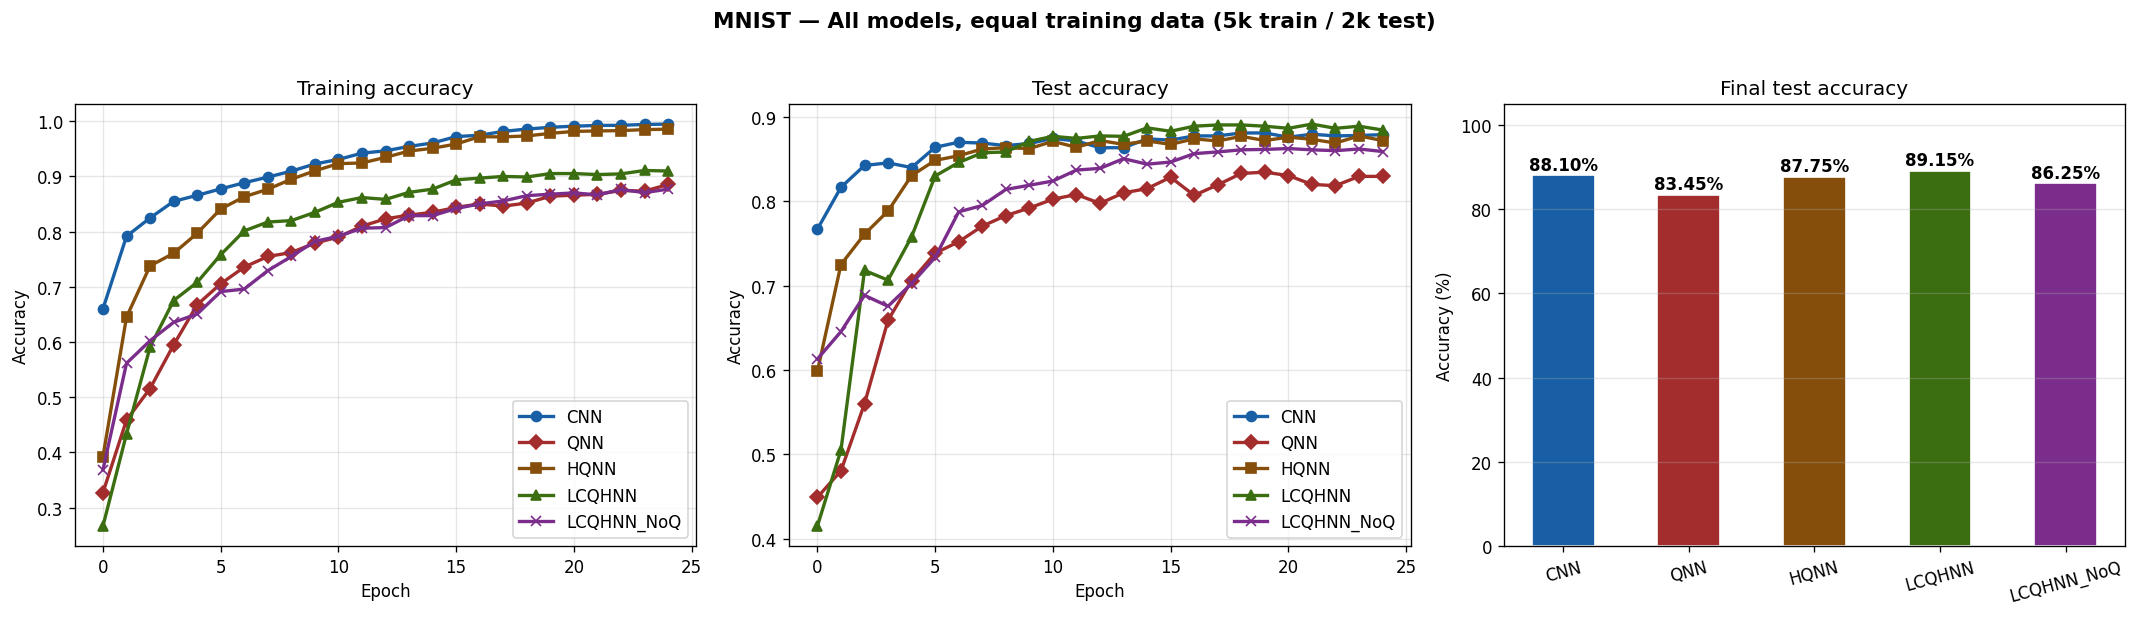

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

colors = {
    'CNN':        '#185FA5',
    'QNN':        '#A32D2D',
    'HQNN':       '#854F0B',
    'LCQHNN':     '#3B6D11',
    'LCQHNN_NoQ': '#7B2D8B',   # purple — stands out as ablation
}
markers = {'CNN':'o','QNN':'D','HQNN':'s','LCQHNN':'^','LCQHNN_NoQ':'x'}

all_trains = [cnn_train, qnn_train, hqnn_train, lcqhnn_train, noq_train]
all_tests  = [cnn_test,  qnn_test,  hqnn_test,  lcqhnn_test,  noq_test]
names      = list(colors.keys())

for i, (name, tr, te) in enumerate(zip(names, all_trains, all_tests)):
    axes[0].plot(tr, marker=markers[name], lw=2, label=name, color=colors[name])
    axes[1].plot(te, marker=markers[name], lw=2, label=name, color=colors[name])

for ax, title in zip(axes[:2], ['Training accuracy', 'Test accuracy']):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)

# Bar chart
final_accs = [max(r)*100 for r in all_tests]
bars = axes[2].bar(names, final_accs, color=list(colors.values()),
                   width=0.5, edgecolor='white')
for bar, acc in zip(bars, final_accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].set_title('Final test accuracy', fontsize=12)
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim(0, 105)
axes[2].grid(True, axis='y', alpha=0.3)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('MNIST — All models, equal training data (5k train / 2k test)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Ablation interpretation

The cell below prints a clear statement about what the ablation shows.
This is the result you need to report honestly in your paper —
regardless of which direction it goes.

In [19]:
lcq_acc  = results['LCQHNN']
noq_acc  = results['LCQHNN_NoQ']
hqnn_acc = results['HQNN']

print('===== ABLATION ANALYSIS =====')
print(f'LCQHNN (with quantum):     {lcq_acc*100:.2f}%')
print(f'LCQHNN_NoQ (no quantum):   {noq_acc*100:.2f}%')
print(f'HQNN (baseline):           {hqnn_acc*100:.2f}%')
print()

q_delta = (lcq_acc - noq_acc) * 100
h_delta = (lcq_acc - hqnn_acc) * 100

print(f'Quantum contribution (LCQHNN vs NoQ): {q_delta:+.2f}pp')
print(f'LCQHNN vs HQNN:                       {h_delta:+.2f}pp')
print()

if q_delta > 1.0:
    print('INTERPRETATION: Quantum layer provides a meaningful improvement (>1pp).')
    print('This supports the claim of quantum contribution in LCQHNN.')
elif q_delta > 0:
    print('INTERPRETATION: Quantum layer shows marginal positive effect (<1pp).')
    print('Difference is likely within random seed variance. Run 5+ seeds to confirm.')
else:
    print('INTERPRETATION: Classical bottleneck matches or beats the quantum layer.')
    print('You cannot claim quantum advantage. Either improve the quantum circuit')
    print('(more qubits, data re-uploading) or reframe the paper contribution.')

===== ABLATION ANALYSIS =====
LCQHNN (with quantum):     89.15%
LCQHNN_NoQ (no quantum):   86.25%
HQNN (baseline):           87.75%

Quantum contribution (LCQHNN vs NoQ): +2.90pp
LCQHNN vs HQNN:                       +1.40pp

INTERPRETATION: Quantum layer provides a meaningful improvement (>1pp).
This supports the claim of quantum contribution in LCQHNN.


## Per-class metrics for all models

In [20]:
for name, model in [('CNN', cnn), ('QNN', qnn), ('HQNN', hqnn),
                    ('LCQHNN', lcqhnn), ('LCQHNN_NoQ', lcqhnn_noq)]:
    print(f'\n===== {name} =====')
    print_metrics(model, test_loader)


===== CNN =====
              precision    recall  f1-score   support

           0     0.8232    0.8150    0.8191       200
           1     0.9799    0.9750    0.9774       200
           2     0.7723    0.7800    0.7761       200
           3     0.8647    0.8950    0.8796       200
           4     0.7783    0.7900    0.7841       200
           5     0.9512    0.9750    0.9630       200
           6     0.7031    0.6750    0.6888       200
           7     0.9497    0.9450    0.9474       200
           8     0.9796    0.9600    0.9697       200
           9     0.9849    0.9800    0.9825       200

    accuracy                         0.8790      2000
   macro avg     0.8787    0.8790    0.8788      2000
weighted avg     0.8787    0.8790    0.8788      2000


===== QNN =====
              precision    recall  f1-score   support

           0     0.8342    0.7800    0.8062       200
           1     0.9844    0.9450    0.9643       200
           2     0.6986    0.7300    0.7139 

## Confusion matrices

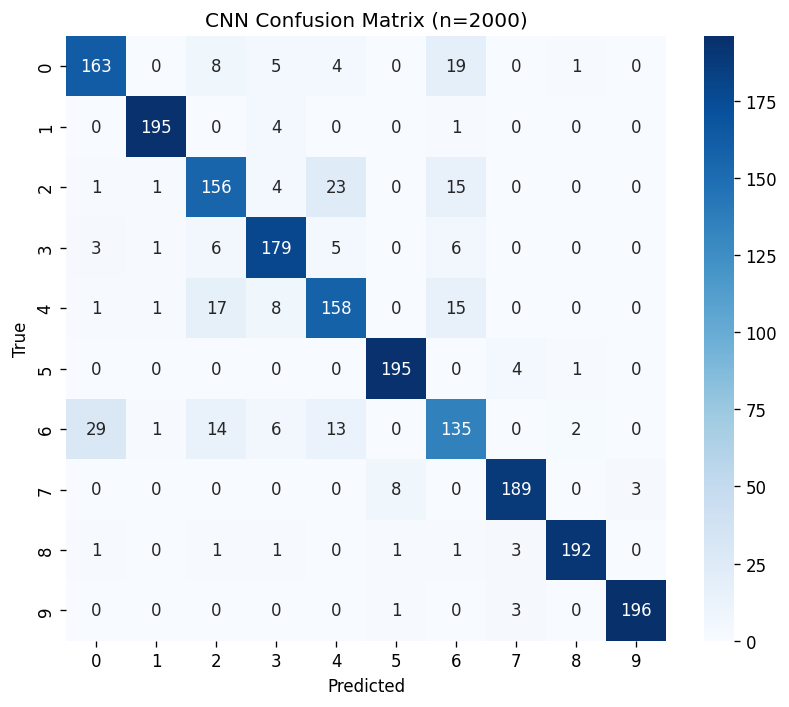

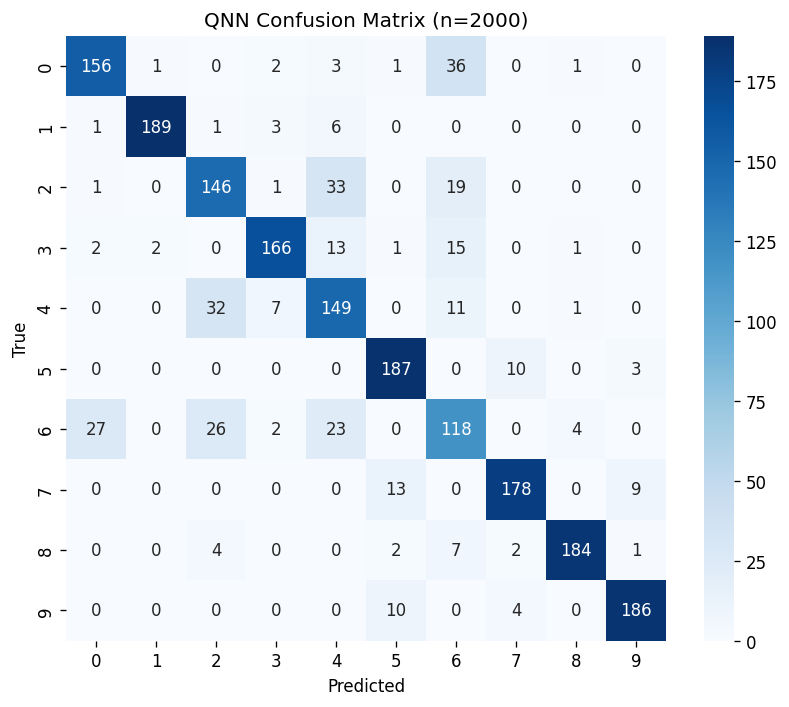

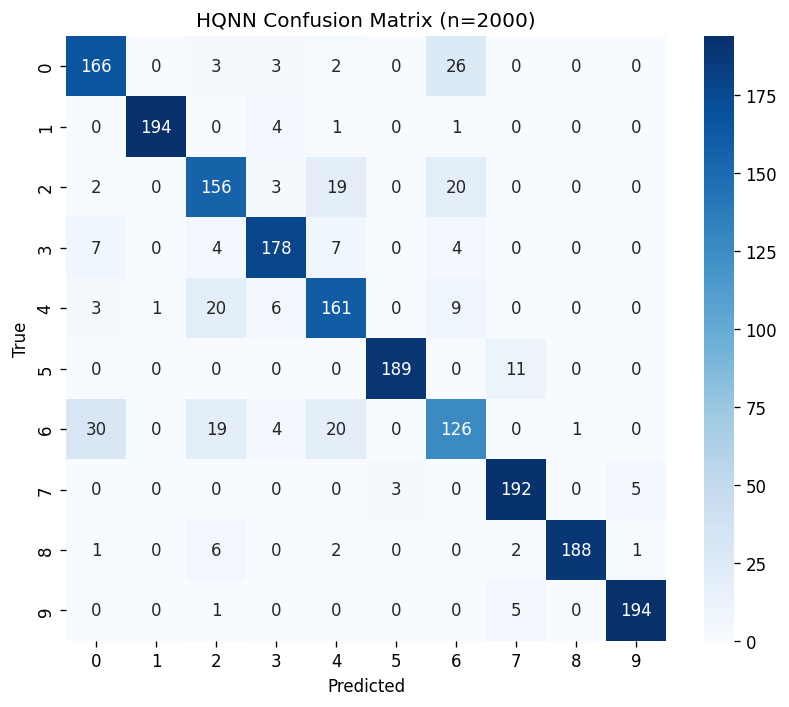

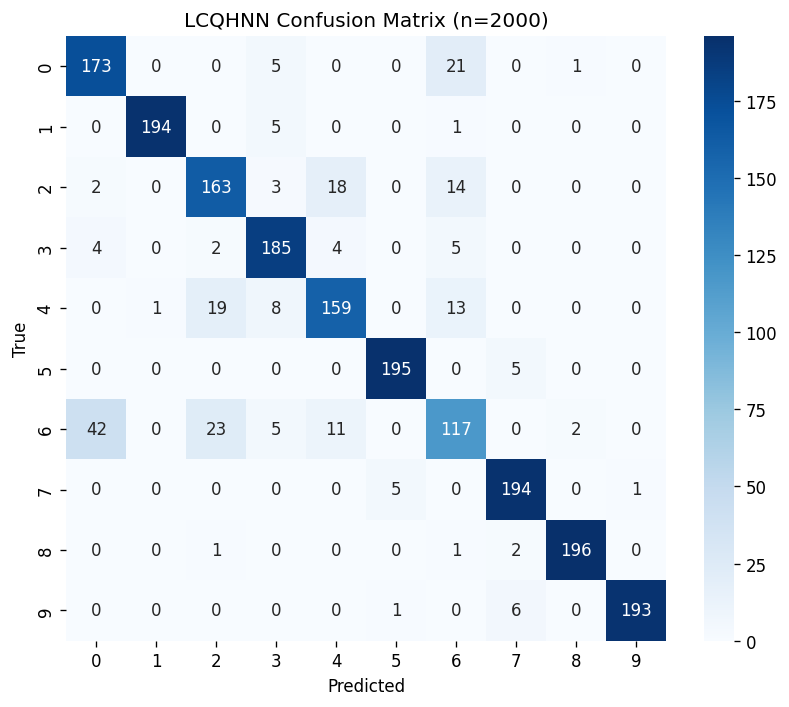

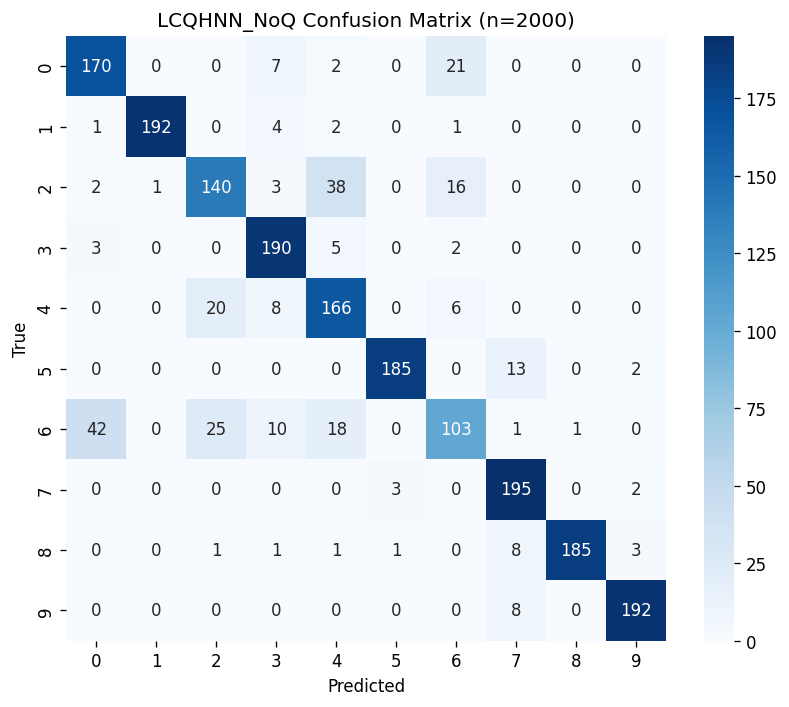

In [21]:
for name, model in [('CNN', cnn), ('QNN', qnn), ('HQNN', hqnn),
                    ('LCQHNN', lcqhnn), ('LCQHNN_NoQ', lcqhnn_noq)]:
    plot_confusion(model, name, test_loader)

## Grad-CAM (CNN, HQNN, LCQHNN only)

Note: GradCAM is only applied to models with convolutional layers.
QNN has no spatial structure so no valid spatial heatmap can be produced.

In [22]:
class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self.grad = self.act = None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'act',o))
        layer.register_full_backward_hook(lambda m,i,o: setattr(self,'grad',o[0]))

    def generate(self, x, cls):
        self.model.eval()
        out = self.model(x)
        self.model.zero_grad()
        out[:, cls].sum().backward()
        w   = self.grad.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w * self.act).sum(1))
        return cam


cam_cnn     = GradCAM(cnn,     cnn.conv[3])
cam_hqnn    = GradCAM(hqnn,    hqnn.conv[3])
cam_lcqhnn  = GradCAM(lcqhnn,  lcqhnn.conv[3])
cam_noq     = GradCAM(lcqhnn_noq, lcqhnn_noq.conv[3])

print('GradCAM hooks registered for CNN, HQNN, LCQHNN, LCQHNN_NoQ')

GradCAM hooks registered for CNN, HQNN, LCQHNN, LCQHNN_NoQ


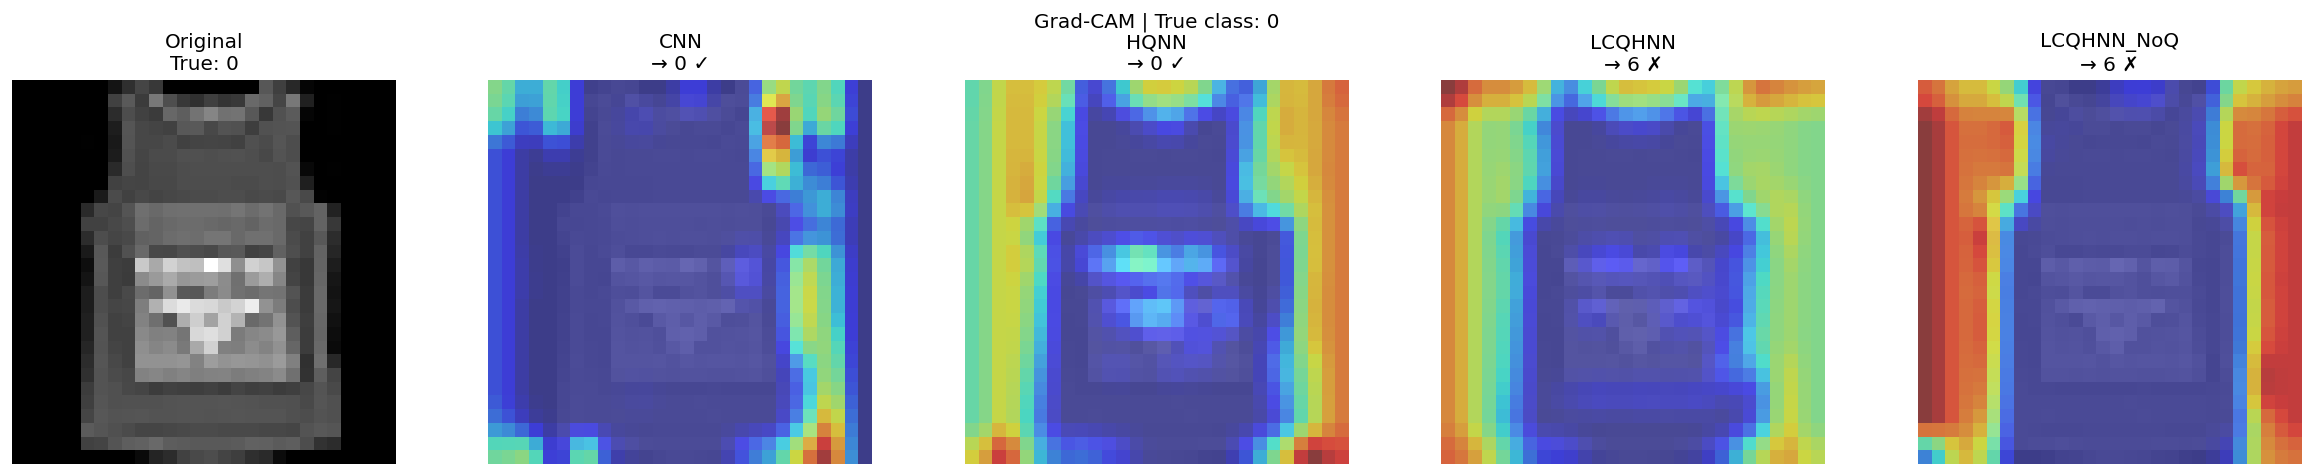

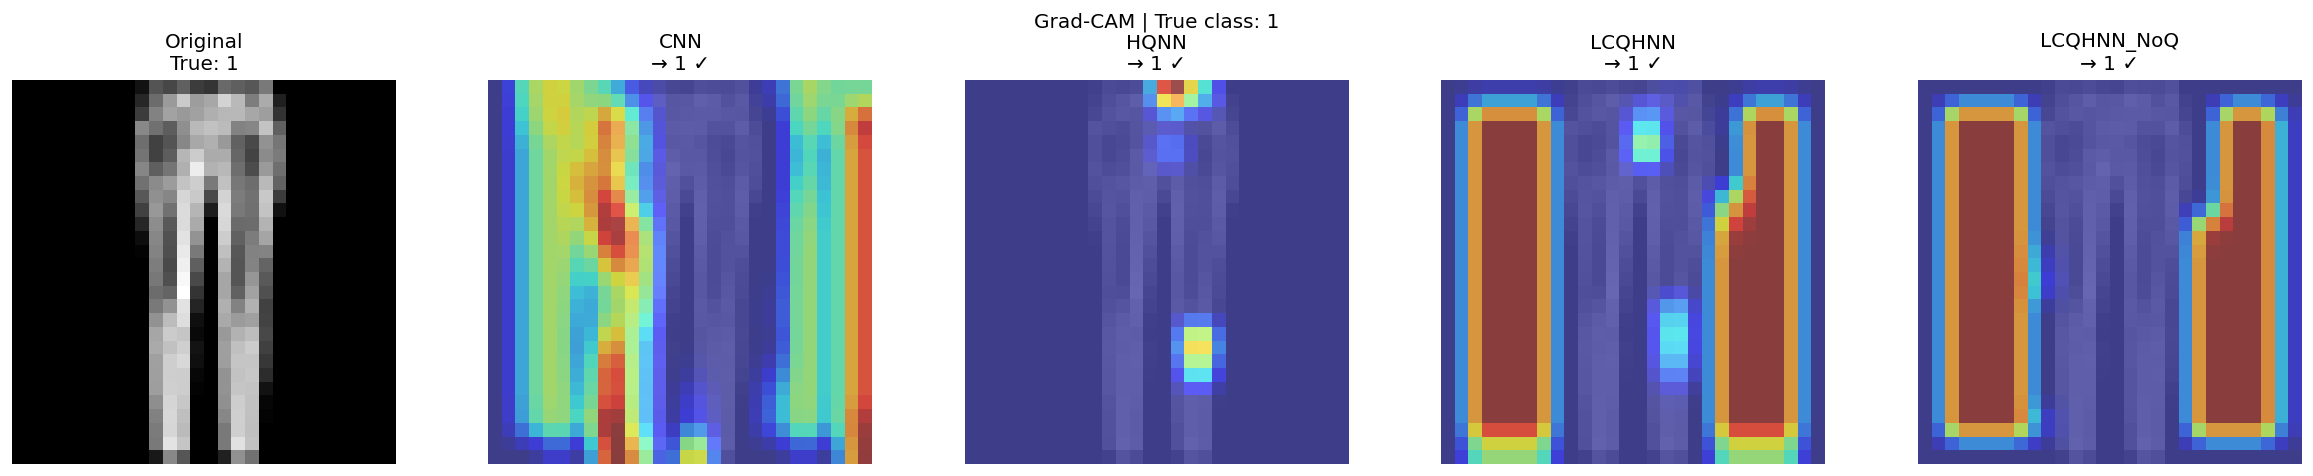

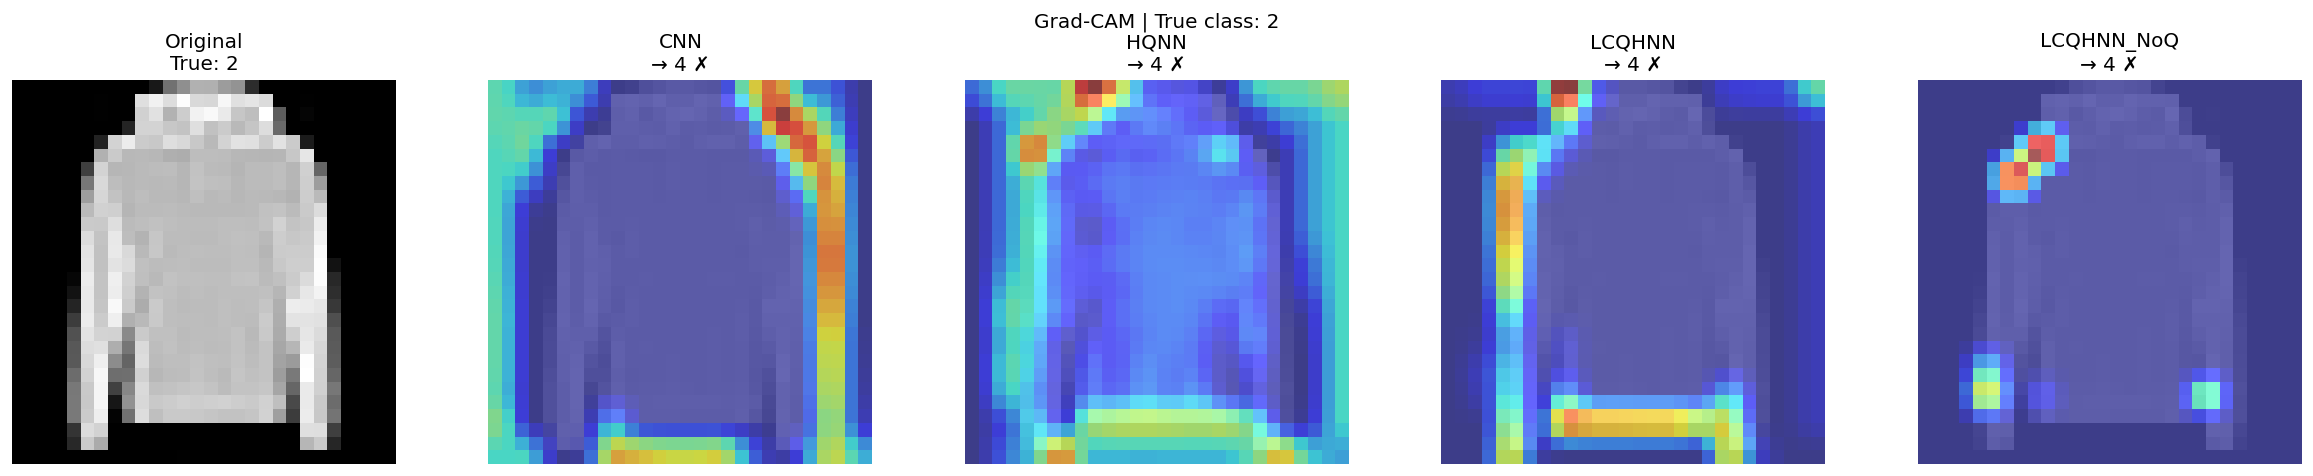

In [23]:
def show_gradcam_comparison(test_loader, class_idx=0):
    """Show Grad-CAM for CNN, HQNN, LCQHNN, LCQHNN_NoQ side by side."""
    # Search full loader for a sample of the target class
    found_images = found_labels = None
    found_i = None
    for images, labels in test_loader:
        for idx in range(len(labels)):
            if labels[idx].item() == class_idx:
                found_images = images
                found_labels = labels
                found_i = idx
                break
        if found_i is not None:
            break
    if found_i is None:
        print(f'Class {class_idx} not found in test loader')
        return

    img_np = found_images[found_i].squeeze().numpy()
    x = found_images[found_i:found_i+1].to(device)

    configs = [
        ('CNN',          cam_cnn,    cnn),
        ('HQNN',         cam_hqnn,   hqnn),
        ('LCQHNN',       cam_lcqhnn, lcqhnn),
        ('LCQHNN_NoQ',   cam_noq,    lcqhnn_noq),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(20, 4), dpi=120)
    axes[0].imshow(img_np, cmap='gray')
    axes[0].set_title(f'Original\nTrue: {class_idx}')
    axes[0].axis('off')

    for ax, (name, cam_obj, model) in zip(axes[1:], configs):
        heatmap = cam_obj.generate(x, class_idx)
        heatmap = F.interpolate(heatmap.unsqueeze(1).float(),
                                size=(28,28), mode='bilinear',
                                align_corners=False).squeeze().cpu().detach().numpy()
        if heatmap.max() > heatmap.min():
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
        with torch.no_grad():
            pred = model(x).argmax(1).item()
        correct = '✓' if pred == class_idx else '✗'
        ax.imshow(img_np, cmap='gray', alpha=0.4)
        ax.imshow(heatmap, cmap='jet', alpha=0.6)
        ax.set_title(f'{name}\n→ {pred} {correct}')
        ax.axis('off')

    plt.suptitle(f'Grad-CAM | True class: {class_idx}', fontsize=12)
    plt.tight_layout()
    plt.show()


# Show for digits 0, 1, 2
for cls in [0, 1, 2]:
    show_gradcam_comparison(test_loader, class_idx=cls)
